In [1]:
import numpy as np
from tqdm.auto import tqdm

from utils.plot import *

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, datasets
from torch.utils.data import Dataset, DataLoader

In [2]:
DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

print("Using PyTorch version: {}, Device: {}".format(torch.__version__, DEVICE))
print("Using torchtext version: {}".format(torchtext.__version__))

Using PyTorch version: 1.12.0, Device: cpu
Using torchtext version: 0.13.0


In [9]:
# ----- Utils -----

In [10]:
def train(model, train_loader, optimizer, scheduler = None):
    model.train()
    train_loss = 0
    correct = 0
    tqdm_bar = tqdm(enumerate(train_loader))
    for batch_idx, (image, label) in tqdm_bar:
        image = image.to(DEVICE)
        label = label.to(DEVICE)
        optimizer.zero_grad()
        output = model(image)
        loss = criterion(output, label)
        loss.backward()
        train_loss += loss.item()
        prediction = output.max(1, keepdim = True)[1]
        correct += prediction.eq(label.view_as(prediction)).sum().item()
        optimizer.step()
        tqdm_bar.set_description("Epoch {} - train loss: {:.6f}".format(epoch, loss.item()))
    if scheduler is not None:
        scheduler.step()
    train_loss /= len(train_loader.dataset)
    train_acc = 100. * correct / len(train_loader.dataset)
    return train_loss, train_acc

def evaluate(model, test_loader):
    model.eval()
    test_loss = 0
    correct = 0

    with torch.no_grad():
        for image, label in tqdm(test_loader):
            image = image.to(DEVICE)
            label = label.to(DEVICE)
            output = model(image)
            test_loss += criterion(output, label).item()
            prediction = output.max(1, keepdim = True)[1]
            correct += prediction.eq(label.view_as(prediction)).sum().item()
    
    test_loss /= len(test_loader.dataset)
    test_acc = 100. * correct / len(test_loader.dataset)
    return test_loss, test_acc

In [ ]:
# ----- Load Fashion MNIST -----

In [3]:
BATCH_SIZE = 1024

train_loader = DataLoader(datasets.FashionMNIST('./data/',
                          train=True, download=True,
                          transform=transforms.Compose([transforms.ToTensor(),
                                                        transforms.Normalize((0.1307,), (0.3081,))])), # train data에서 흑,백의 평균값이 0.1307, 0.3081 -> mean centered
                          batch_size=BATCH_SIZE, shuffle=True)

test_loader = DataLoader(datasets.FashionMNIST('./data/',
                          train=False,
                          transform=transforms.Compose([transforms.ToTensor(),
                                                        transforms.Normalize((0.1307,), (0.3081,))])),
                          batch_size=BATCH_SIZE, shuffle=True)


Extracting ./data/FashionMNIST/raw/train-images-idx3-ubyte.gz to ./data/FashionMNIST/raw




Extracting ./data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw




Extracting ./data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to ./data/FashionMNIST/raw




Extracting ./data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



/Users/jeongmoonwon/opt/anaconda3/lib/python3.8/site-packages/torchvision/datasets/mnist.py:498: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at  /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:178.)
  return torch.from_numpy(parsed.astype(m[2], copy=False)).view(*s)


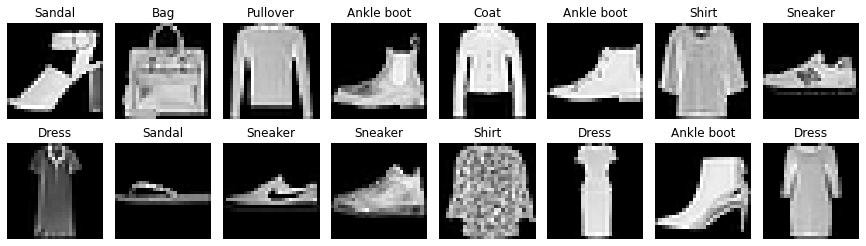

In [4]:
plot_dataset(train_loader)

In [5]:
# ----- Custom Dropout -----

In [ ]:
# 1. numpy
w1 = np.array([[.2, -.5, .1, 2.],
              [1.5, 1.3, 2.1, 0.],
              [0., .25, .2, -.3]])
data = np.array([56, 231, 24, 2]).reshape(4, 1)
b1 = np.array([1.1, 3.2, -1.2]).reshape(3, 1)

w2 = np.array([.3, 1.5, -.5]).reshape(1, 3)
b2 = 0.8

p = 0.5

def train_step(data, p):
    h1 = np.maximum(0, np.dot(w1, data) + b1) 
    print(h1, 'h1')
    u1 = (np.random.rand(*h1.shape) < p) / p # h1의 값들 중 일부가 사라지므로 h2의 값이 전반적으로 줄어들텐데 이를 방지하기 위해 p로 나눠사 깂을 늘림
    print(u1, 'u1')
    h1 *= u1 # True이면 1을 곱하고 False이먄 0을 곱함으로써 dropout
    print(h1, 'h1')
    h2 = np.maximum(0, np.dot(w2, h1) + b2) # h1의 값들 중 일부가 사라지므로 h2의 값이 전반적으로 줄어들 것임
    print(h2, 'h2')
    u2 = (np.random.rand(*h2.shape) < p) / p
    print(u2, 'u2')
    h2 *= u2
    print(h2, 'h2')

def test_step(data):
    h1 = np.maximum(0, np.dot(w1, data) + b1) # test에서는 p와 무관하게 작동하도록 함
    print('h1', h1)
    h2 = np.maximum(0, np.dot(w2, h1) + b2) 
    print('h2', h2)
    
train_step(data, p)
test_step(data)

In [6]:
# 2. pytorch
class Dropout(nn.Module):
    def __init__(self, p=0.5):
        super(Dropout, self).__init__()
        if p < 0 or p > 1:
            raise ValueError("dropout probability has to be between 0 and 1, "
                             "but got {}".format(p))
        self.p = p

    def forward(self, input):
        mask = (np.random.rand(*input.shape) < self.p) / self.p
        output = input * torch.Tensor(mask).to(DEVICE)
        return output.to(DEVICE)

    def __repr__(self):
        return self.__class__.__name__ + '(' + 'p=' + str(self.p) + ')'

In [ ]:
# 예시로 확인
x = torch.rand((3, 2))
Dropout(p=0.5)(x)

In [7]:
# dropout 하지 않는 경우
class SimpleClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 10)  
        
    def forward(self, x):
        x = x.view(x.shape[0], -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.log_softmax(self.fc4(x), dim=1)
        return x



[EPOCH: 1], 	LR: 0.0010, 	Train Loss: 0.0008, 	Train Accuracy: 72.34 %, 	Test Loss: 0.0005, 	Test Accuracy: 80.45 % 





[EPOCH: 2], 	LR: 0.0010, 	Train Loss: 0.0004, 	Train Accuracy: 83.94 %, 	Test Loss: 0.0004, 	Test Accuracy: 84.33 % 





[EPOCH: 3], 	LR: 0.0010, 	Train Loss: 0.0004, 	Train Accuracy: 86.16 %, 	Test Loss: 0.0004, 	Test Accuracy: 85.20 % 





[EPOCH: 4], 	LR: 0.0010, 	Train Loss: 0.0004, 	Train Accuracy: 86.89 %, 	Test Loss: 0.0004, 	Test Accuracy: 86.12 % 





[EPOCH: 5], 	LR: 0.0010, 	Train Loss: 0.0003, 	Train Accuracy: 87.73 %, 	Test Loss: 0.0004, 	Test Accuracy: 86.77 % 



...



[EPOCH: 16], 	LR: 0.0010, 	Train Loss: 0.0002, 	Train Accuracy: 92.06 %, 	Test Loss: 0.0003, 	Test Accuracy: 89.10 % 





[EPOCH: 17], 	LR: 0.0010, 	Train Loss: 0.0002, 	Train Accuracy: 92.28 %, 	Test Loss: 0.0003, 	Test Accuracy: 88.84 % 





[EPOCH: 18], 	LR: 0.0010, 	Train Loss: 0.0002, 	Train Accuracy: 92.66 %, 	Test Loss: 0.0003, 	Test Accuracy: 88.73 % 





[EPOCH: 19], 	LR: 0.0010, 	Train Loss: 0.0002, 	Train Accuracy: 92.75 %, 	Test Loss: 0.0003, 	Test Accuracy: 88.15 % 





[EPOCH: 20], 	LR: 0.0010, 	Train Loss: 0.0002, 	Train Accuracy: 92.82 %, 	Test Loss: 0.0003, 	Test Accuracy: 89.02 % 



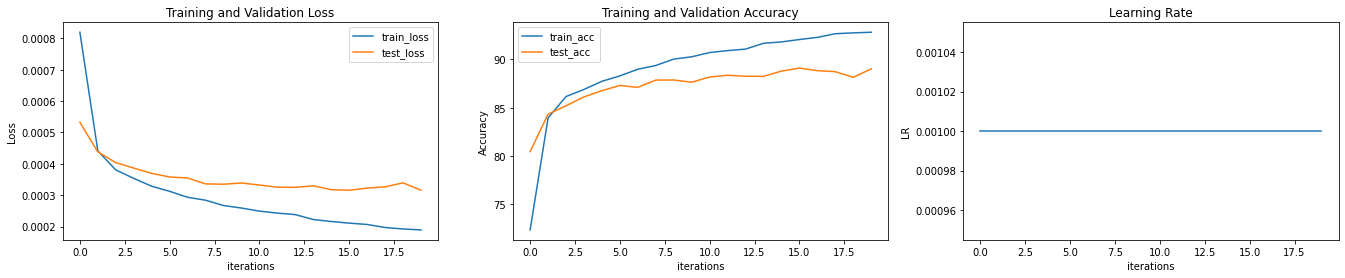

In [11]:
EPOCHS = 20
model = SimpleClassifier().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)
criterion = nn.CrossEntropyLoss()
history = {'train_loss':[], 'train_acc':[], 'test_loss':[], 'test_acc':[], 'lr':[]}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_accuracy = train(model, train_loader, optimizer)
    test_loss, test_accuracy = evaluate(model, test_loader)
    print("\n[EPOCH: {}], \tLR: {:.4f}, \tTrain Loss: {:.4f}, \tTrain Accuracy: {:.2f} %, \tTest Loss: {:.4f}, \tTest Accuracy: {:.2f} % \n".format(
        epoch, optimizer.param_groups[0]['lr'], train_loss, train_accuracy, test_loss, test_accuracy))
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_accuracy)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_accuracy)
    history['lr'].append(optimizer.param_groups[0]['lr'])
    
plot_history(history)

In [12]:
# dropout ratioㄹ를  0.3으로 하는 경우
class RegClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784,256)
        self.fc2 = nn.Linear(256,128)
        self.fc3 = nn.Linear(128,64)
        self.fc4 = nn.Linear(64,10)
        self.dropout = Dropout(p=0.3)
    
    def forward(self,x):
        x = x.view(x.shape[0],-1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = F.relu(self.fc3(x))
        x = self.dropout(x)
        x = F.log_softmax(self.fc4(x),dim=1)
        
        return x



[EPOCH: 1], 	LR: 0.0010, 	Train Loss: 0.0017, 	Train Accuracy: 35.49 %, 	Test Loss: 0.0012, 	Test Accuracy: 53.75 % 





[EPOCH: 2], 	LR: 0.0010, 	Train Loss: 0.0010, 	Train Accuracy: 60.51 %, 	Test Loss: 0.0009, 	Test Accuracy: 64.97 % 





[EPOCH: 3], 	LR: 0.0010, 	Train Loss: 0.0008, 	Train Accuracy: 67.91 %, 	Test Loss: 0.0008, 	Test Accuracy: 69.88 % 





[EPOCH: 4], 	LR: 0.0010, 	Train Loss: 0.0008, 	Train Accuracy: 71.18 %, 	Test Loss: 0.0008, 	Test Accuracy: 71.69 % 





[EPOCH: 5], 	LR: 0.0010, 	Train Loss: 0.0007, 	Train Accuracy: 73.90 %, 	Test Loss: 0.0007, 	Test Accuracy: 73.77 % 



...



[EPOCH: 16], 	LR: 0.0010, 	Train Loss: 0.0006, 	Train Accuracy: 81.37 %, 	Test Loss: 0.0006, 	Test Accuracy: 79.76 % 





[EPOCH: 17], 	LR: 0.0010, 	Train Loss: 0.0005, 	Train Accuracy: 81.41 %, 	Test Loss: 0.0006, 	Test Accuracy: 80.03 % 





[EPOCH: 18], 	LR: 0.0010, 	Train Loss: 0.0006, 	Train Accuracy: 81.50 %, 	Test Loss: 0.0006, 	Test Accuracy: 80.18 % 





[EPOCH: 19], 	LR: 0.0010, 	Train Loss: 0.0005, 	Train Accuracy: 81.71 %, 	Test Loss: 0.0006, 	Test Accuracy: 80.60 % 





[EPOCH: 20], 	LR: 0.0010, 	Train Loss: 0.0005, 	Train Accuracy: 81.98 %, 	Test Loss: 0.0006, 	Test Accuracy: 80.47 % 



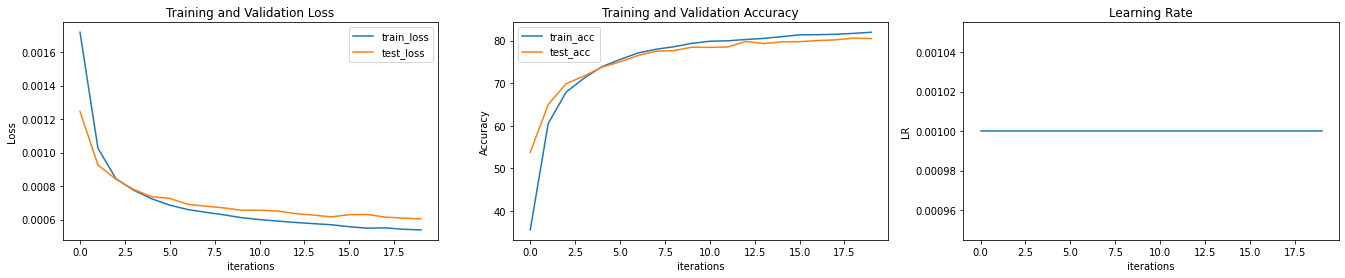

In [13]:
EPOCHS = 20
model = RegClassifier().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)
criterion = nn.CrossEntropyLoss()
history = {'train_loss':[], 'train_acc':[], 'test_loss':[], 'test_acc':[], 'lr':[]}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_accuracy = train(model, train_loader, optimizer)
    test_loss, test_accuracy = evaluate(model, test_loader)
    print("\n[EPOCH: {}], \tLR: {:.4f}, \tTrain Loss: {:.4f}, \tTrain Accuracy: {:.2f} %, \tTest Loss: {:.4f}, \tTest Accuracy: {:.2f} % \n".format(
        epoch, optimizer.param_groups[0]['lr'], train_loss, train_accuracy, test_loss, test_accuracy))
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_accuracy)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_accuracy)
    history['lr'].append(optimizer.param_groups[0]['lr'])
    
plot_history(history)

In [14]:
# dropout ratio가 0.7인 경우 (too high)
class RegClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784,256)
        self.fc2 = nn.Linear(256,128)
        self.fc3 = nn.Linear(128,64)
        self.fc4 = nn.Linear(64,10)
        self.dropout = Dropout(p=0.7)
    
    def forward(self,x):
        x = x.view(x.shape[0],-1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = F.relu(self.fc3(x))
        x = self.dropout(x)
        x = F.log_softmax(self.fc4(x),dim=1)
        
        return x



[EPOCH: 1], 	LR: 0.0010, 	Train Loss: 0.0010, 	Train Accuracy: 62.21 %, 	Test Loss: 0.0006, 	Test Accuracy: 76.43 % 





[EPOCH: 2], 	LR: 0.0010, 	Train Loss: 0.0005, 	Train Accuracy: 80.26 %, 	Test Loss: 0.0005, 	Test Accuracy: 81.35 % 





[EPOCH: 3], 	LR: 0.0010, 	Train Loss: 0.0005, 	Train Accuracy: 83.73 %, 	Test Loss: 0.0005, 	Test Accuracy: 83.37 % 





[EPOCH: 4], 	LR: 0.0010, 	Train Loss: 0.0004, 	Train Accuracy: 84.99 %, 	Test Loss: 0.0005, 	Test Accuracy: 84.06 % 





[EPOCH: 5], 	LR: 0.0010, 	Train Loss: 0.0004, 	Train Accuracy: 86.07 %, 	Test Loss: 0.0004, 	Test Accuracy: 84.96 % 



...



[EPOCH: 16], 	LR: 0.0010, 	Train Loss: 0.0003, 	Train Accuracy: 89.75 %, 	Test Loss: 0.0004, 	Test Accuracy: 86.83 % 





[EPOCH: 17], 	LR: 0.0010, 	Train Loss: 0.0003, 	Train Accuracy: 89.83 %, 	Test Loss: 0.0004, 	Test Accuracy: 87.36 % 





[EPOCH: 18], 	LR: 0.0010, 	Train Loss: 0.0003, 	Train Accuracy: 90.08 %, 	Test Loss: 0.0004, 	Test Accuracy: 87.50 % 





[EPOCH: 19], 	LR: 0.0010, 	Train Loss: 0.0003, 	Train Accuracy: 90.23 %, 	Test Loss: 0.0004, 	Test Accuracy: 87.43 % 





[EPOCH: 20], 	LR: 0.0010, 	Train Loss: 0.0003, 	Train Accuracy: 90.31 %, 	Test Loss: 0.0004, 	Test Accuracy: 87.50 % 



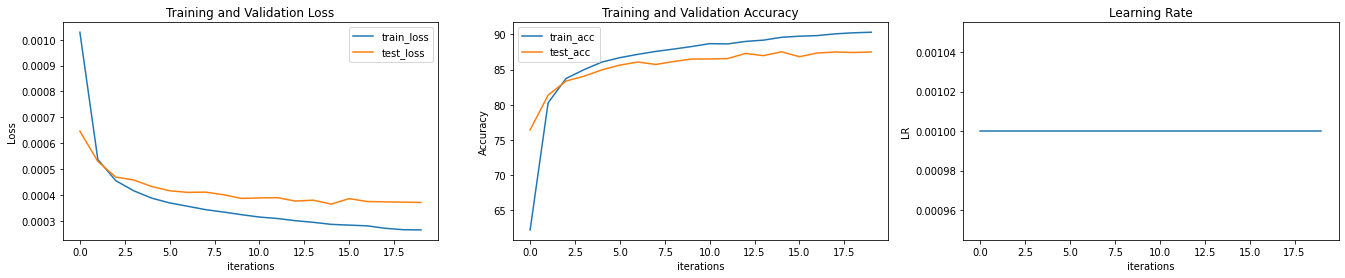

In [15]:
EPOCHS = 20
model = RegClassifier().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)
criterion = nn.CrossEntropyLoss()
history = {'train_loss':[], 'train_acc':[], 'test_loss':[], 'test_acc':[], 'lr':[]}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_accuracy = train(model, train_loader, optimizer)
    test_loss, test_accuracy = evaluate(model, test_loader)
    print("\n[EPOCH: {}], \tLR: {:.4f}, \tTrain Loss: {:.4f}, \tTrain Accuracy: {:.2f} %, \tTest Loss: {:.4f}, \tTest Accuracy: {:.2f} % \n".format(
        epoch, optimizer.param_groups[0]['lr'], train_loss, train_accuracy, test_loss, test_accuracy))
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_accuracy)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_accuracy)
    history['lr'].append(optimizer.param_groups[0]['lr'])
    
plot_history(history)

In [ ]:
# ----- Add regularization to the model -----

In [16]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=8),
            nn.ReLU(),
            nn.Dropout(p=0.3), # 우리가 구현한 Dropout 클래스 대신 nn.dropout 사용 가능
            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Flatten(),
            nn.Linear(3136, 512),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(512, 10),
        )
    
    def forward(self,x):
        x = self.conv(x)
        return x



[EPOCH: 1], 	LR: 0.0009, 	Train Loss: 0.0008, 	Train Accuracy: 70.98 %, 	Test Loss: 0.0005, 	Test Accuracy: 81.67 % 





[EPOCH: 2], 	LR: 0.0008, 	Train Loss: 0.0004, 	Train Accuracy: 83.78 %, 	Test Loss: 0.0004, 	Test Accuracy: 85.49 % 





[EPOCH: 3], 	LR: 0.0007, 	Train Loss: 0.0004, 	Train Accuracy: 85.69 %, 	Test Loss: 0.0004, 	Test Accuracy: 86.37 % 





[EPOCH: 4], 	LR: 0.0007, 	Train Loss: 0.0004, 	Train Accuracy: 86.96 %, 	Test Loss: 0.0004, 	Test Accuracy: 86.67 % 





[EPOCH: 5], 	LR: 0.0006, 	Train Loss: 0.0003, 	Train Accuracy: 87.36 %, 	Test Loss: 0.0004, 	Test Accuracy: 87.81 % 





[EPOCH: 6], 	LR: 0.0005, 	Train Loss: 0.0003, 	Train Accuracy: 88.19 %, 	Test Loss: 0.0003, 	Test Accuracy: 88.10 % 





[EPOCH: 7], 	LR: 0.0005, 	Train Loss: 0.0003, 	Train Accuracy: 88.45 %, 	Test Loss: 0.0003, 	Test Accuracy: 88.54 % 





[EPOCH: 8], 	LR: 0.0004, 	Train Loss: 0.0003, 	Train Accuracy: 88.93 %, 	Test Loss: 0.0003, 	Test Accuracy: 88.98 % 





[EPOCH: 9], 	LR: 0.0004, 	Train Loss: 0.0003, 	Train Accuracy: 89.20 %, 	Test Loss: 0.0003, 	Test Accuracy: 88.61 % 





[EPOCH: 10], 	LR: 0.0003, 	Train Loss: 0.0003, 	Train Accuracy: 89.55 %, 	Test Loss: 0.0003, 	Test Accuracy: 89.29 % 



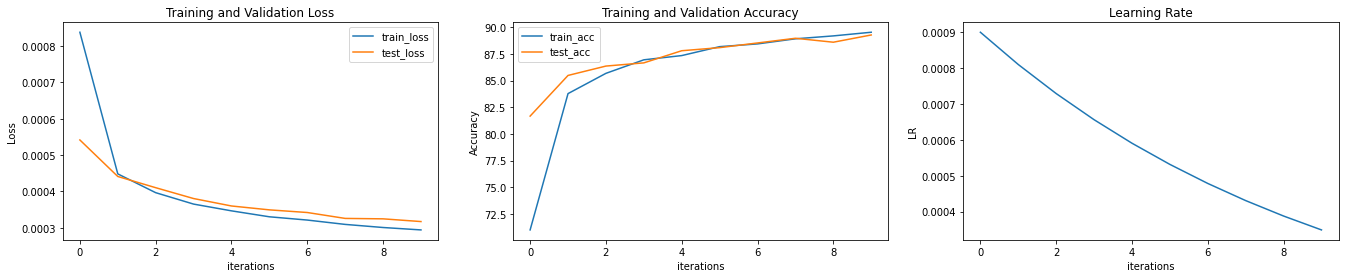

In [19]:
# early stopping, weight_decay
from torch.optim.lr_scheduler import ExponentialLR as ExponentialLR

EPOCHS = 10
best_loss = 1000 # 초기값 설정
patience = 0
history = {'train_loss':[], 'train_acc':[], 'test_loss':[], 'test_acc':[], 'lr':[]}

model = Model().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001, weight_decay=0.01) # weight_decay - L1, L2 regularization
scheduler = ExponentialLR(optimizer, gamma=0.9)
criterion = nn.CrossEntropyLoss()

for epoch in range(1, EPOCHS + 1):
    train_loss, train_accuracy = train(model, train_loader, optimizer, scheduler)
    test_loss, test_accuracy = evaluate(model, test_loader)
    print("\n[EPOCH: {}], \tLR: {:.4f}, \tTrain Loss: {:.4f}, \tTrain Accuracy: {:.2f} %, \tTest Loss: {:.4f}, \tTest Accuracy: {:.2f} % \n".format(
        epoch, optimizer.param_groups[0]['lr'], train_loss, train_accuracy, test_loss, test_accuracy))

    # test_loss가 증가하는 시점에서 stop training
    if test_loss < best_loss:
        best_loss = test_loss
        patience = 0
    else:
        patience += 1
        if patience >= 5:
            break

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_accuracy)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_accuracy)
    history['lr'].append(optimizer.param_groups[0]['lr'])
    
plot_history(history)

# 32:11

In [ ]:
# ----- Custom Learning Rate Scheduler -----

In [ ]:
class ScheduledOptim():

    def __init__(self, optimizer, n_warmup_steps, decay_rate, steps=None):
        self._optimizer = optimizer
        self.n_warmup_steps = n_warmup_steps
        self.decay = decay_rate
        self.n_steps = 0
        self.steps = steps
        self.initial_lr = optimizer.param_groups[0]['lr']
        self.current_lr = optimizer.param_groups[0]['lr']

    def zero_grad(self):
        self._optimizer.zero_grad()

    def step(self):
        self.update()
        # self._optimizer.step()
    
    def get_lr(self):
        return self.current_lr
    
    def update(self):
        #### TODO ####

        ##############

        self.n_steps += 1

In [ ]:
EPOCHS = 10
history = {'train_loss':[], 'train_acc':[], 'test_loss':[], 'test_acc':[], 'lr':[]}

model = Model().to(DEVICE)
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
#### TODO ####

##############

for epoch in range(1, EPOCHS + 1):
    lr = scheduler.get_lr()
    train_loss, train_accuracy = train(model, train_loader, optimizer, scheduler)
    test_loss, test_accuracy = evaluate(model, test_loader)
    print("\n[EPOCH: {}], \tLR: {:.5f}, \tTrain Loss: {:.4f}, \tTrain Accuracy: {:.2f} %, \tTest Loss: {:.4f}, \tTest Accuracy: {:.2f} % \n".format(
        epoch, lr, train_loss, train_accuracy, test_loss, test_accuracy))
    
    #### TODO ####

    ##############

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_accuracy)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_accuracy)
    history['lr'].append(lr)
    
plot_history(history)

# RNN Text Classification

In [ ]:
train_data, test_data = torchtext.datasets.AG_NEWS(root='./data')
labels = [_, 'World', 'Sports', 'Business', 'Sci/Tech']
y, x = next(iter(train_data))
print(labels[y])
print(x)

In [ ]:
y, x = next(iter(test_data))
print(labels[y])
print(x)

In [ ]:
set([label for (label, text) in train_data]), set([label for (label, text) in test_data])

In [ ]:
from torchtext.data.utils import get_tokenizer

tokenizer = get_tokenizer('basic_english')
tokenizer("Hi, my name is Joonseok!")

In [ ]:
from torchtext.vocab import build_vocab_from_iterator

def tokens(data_iter):
    for _, text in data_iter:
        yield tokenizer(text)

encoder = build_vocab_from_iterator(tokens(train_data), specials=["<unk>"])
encoder.set_default_index(encoder["<unk>"])

encoder(tokenizer("Hi, my name is Joonseok <unk> !"))

In [ ]:
text_pipeline = lambda x: encoder(tokenizer(x))
label_pipeline = lambda x: int(x) - 1

In [ ]:
iterator = iter(train_data)
sample_batch = []
for _ in range(8):
    sample_batch.append(next(iterator))

In [ ]:
## What happens if we ignore zero-padding

def collate_batch(batch):
    label_list, text_list = [], []
    for (_label, _text) in batch:
        label_list.append(label_pipeline(_label))
        processed_text = torch.tensor(text_pipeline(_text), dtype=torch.int64)
        text_list.append(processed_text)
    label_list = torch.tensor(label_list, dtype=torch.int64)
    text_list = torch.stack(text_list).long()
    return label_list, text_list

In [ ]:
collate_batch(sample_batch)

In [ ]:
MAX_LEN = 32

def collate_batch(batch):
    label_list, text_list = [], []
    for (_label, _text) in batch:
        label_list.append(label_pipeline(_label))
        processed_text = torch.tensor(text_pipeline(_text), dtype=torch.int64)
        if processed_text.size(0) >= MAX_LEN:
            processed_text = processed_text[:MAX_LEN]
        else:
            processed_text = torch.cat([processed_text, 
                                  torch.zeros(MAX_LEN-processed_text.size(0))])
        text_list.append(processed_text)
    label_list = torch.tensor(label_list, dtype=torch.int64)
    text_list = torch.stack(text_list).long()
    return label_list, text_list

In [ ]:
collate_batch(sample_batch)

In [ ]:
dataloader = DataLoader(train_data, batch_size=8, shuffle=False, collate_fn=collate_batch)

y, x = next(iter(dataloader))
x.shape, y.shape

In [ ]:
num_class = len(set([label for (label, text) in train_data]))
vocab_size = len(encoder)
emsize = 64
hidden_dim = 32

embedding = nn.Embedding(vocab_size, emsize)
rnn = nn.RNN(emsize, hidden_dim, 1, nonlinearity='tanh', bias=True, batch_first=True)
fc = nn.Linear(hidden_dim, num_class)

In [ ]:
## Check the tensor shapes after each layer

init_h = torch.randn(1, 8, hidden_dim)
output, hidden = rnn(embedding(x), init_h)
# embedding(x).shape
# fc(output).shape

In [ ]:
class TextClassificationModel(nn.Module):

    def __init__(self, vocab_size, hidden, embed, num_class, batch_size):
        super(TextClassificationModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed)
        self.rnn = nn.RNN(input_size=embed, hidden_size=hidden, 
                          num_layers=1, nonlinearity='tanh', 
                          bias=True, batch_first=True)
        self.fc = nn.Linear(hidden, num_class)
        self.init_weights()

    def init_weights(self):
        initrange = 0.5
        self.embedding.weight.data.uniform_(-initrange, initrange)
        self.fc.weight.data.uniform_(-initrange, initrange)
        self.fc.bias.data.zero_()

    def forward(self, x):
        x = self.embedding(x)
        x, h = self.rnn(x)
        x = torch.mean(x, dim=1)
        return self.fc(x)

In [ ]:
import time

def train(dataloader):
    model.train()
    total_acc, total_count = 0, 0
    log_interval = 500
    start_time = time.time()

    for idx, (label, text) in enumerate(dataloader):
        label, text = label.to(DEVICE), text.to(DEVICE)
        optimizer.zero_grad()
        predicted_label = model(text)
        loss = criterion(predicted_label, label)
        loss.backward()
        optimizer.step()
        total_acc += (predicted_label.argmax(1) == label).sum().item()
        total_count += label.size(0)
        if idx % log_interval == 0 and idx > 0:
            elapsed = time.time() - start_time
            print('| epoch {:3d} | {:5d}/{:5d} batches '
                  '| accuracy {:8.3f}'.format(epoch, idx, len(dataloader),
                                              total_acc/total_count))
            total_acc, total_count = 0, 0
            start_time = time.time()

def evaluate(dataloader):
    model.eval()
    total_acc, total_count = 0, 0

    with torch.no_grad():
        for idx, (label, text) in enumerate(dataloader):
            label, text = label.to(DEVICE), text.to(DEVICE)
            predicted_label = model(text)
            loss = criterion(predicted_label, label)
            total_acc += (predicted_label.argmax(1) == label).sum().item()
            total_count += label.size(0)
    return total_acc/total_count

In [ ]:
from torchtext.data.functional import to_map_style_dataset

# Hyperparameter Setup

EPOCHS = 5
LR = 1
BATCH_SIZE = 64
num_class = len(set([label for (label, text) in train_data]))
vocab_size = len(encoder)
emsize = 64
hidden_dim = 32

model = TextClassificationModel(vocab_size, hidden_dim, emsize, num_class, BATCH_SIZE).to(DEVICE)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 1.0, gamma=0.1)
total_accu = None

train_dataset = to_map_style_dataset(train_data)
test_dataset = to_map_style_dataset(test_data)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                              shuffle=True, collate_fn=collate_batch)
valid_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                              shuffle=True, collate_fn=collate_batch)

In [ ]:
## Train the RNN for text classification

for epoch in range(1, EPOCHS + 1):
    epoch_start_time = time.time()
    train(train_dataloader)
    accu_val = evaluate(valid_dataloader)
    if total_accu is not None and total_accu > accu_val:
      scheduler.step()
    else:
       total_accu = accu_val
    print('-' * 59)
    print('| end of epoch {:3d} | time: {:5.2f}s | '
          'valid accuracy {:8.3f} '.format(epoch,
                                           time.time() - epoch_start_time,
                                           accu_val))
    print('-' * 59)